# Setup and Expected Returns Preparation 

In [2]:
# --- CELL 1: Setup, Imports, and Data Initialization ---
import sys
import os
import pandas as pd
import numpy as np
from pathlib import Path
from sklearn.linear_model import LinearRegression

# 1. Robust Path Handling (Ensures 'scripts' and 'src' can be found)
# This finds the project root folder (portfolio-optimization)
project_root = Path(os.getcwd()).parent
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

# 2. Production Imports
try:
    import scripts.config as cfg
    from src.data_loader import load_processed_data, split_data_chronologically
    from src.optimizer import calculate_covariance, plot_covariance_heatmap, run_optimization
    print("✅ Success: Config and Source Modules imported.")
except ImportError as e:
    print(f"❌ Error: Could not import modules. {e}")

# 3. Define 'future_forecast' (Re-running the logic from Task 3)
# This ensures Task 4 is self-sufficient and won't throw NameErrors
try:
    # Load raw data using the path from config
    df_raw = load_processed_data(cfg.DATA_PATH)
    
    # Split the data
    train_data, test_data = split_data_chronologically(
        df_raw, cfg.TARGET_ASSET, cfg.TRAIN_END_DATE, cfg.TEST_START_DATE
    )

    # Re-generate the 12-month forecast trend (Recursive Linear Regression)
    # This provides the 'expected return' for TSLA required by MPT
    X_train_reg = np.array([train_data.iloc[i-60:i].values for i in range(60, len(train_data))])
    y_train_reg = train_data.iloc[60:].values
    reg_model = LinearRegression().fit(X_train_reg, y_train_reg)

    history = test_data.tolist()
    future_preds = []
    for _ in range(cfg.FORECAST_HORIZON):
        last_window = np.array(history[-60:]).reshape(1, -1)
        pred = reg_model.predict(last_window)[0]
        future_preds.append(pred)
        history.append(pred)

    # Final variable for optimization
    future_forecast = pd.Series(future_preds)
    print(f"✅ Success: 'future_forecast' and 'test_data' are now in memory.")

except Exception as e:
    print(f"❌ Error during initialization: {e}")

✅ Success: Config and Source Modules imported.
✅ Success: 'future_forecast' and 'test_data' are now in memory.


In [3]:
# --- CELL 1: Setup and Expected Returns Preparation ---
import sys
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Setup paths and imports
sys.path.append(os.path.abspath('..'))
from src.optimizer import calculate_covariance, plot_covariance_heatmap, run_optimization
import scripts.config as cfg

# 2. Load Data (Corrected 'parse_dates' parameter)
if not cfg.DATA_PATH.exists():
    print(f"❌ Error: Data not found at {cfg.DATA_PATH}")
else:
    df_all = pd.read_csv(cfg.DATA_PATH, parse_dates=['Date']).set_index('Date')
    
    # Calculate daily returns for the portfolio assets
    all_returns = df_all[cfg.PORTFOLIO_TICKERS].pct_change().dropna()

    # 3. Hybrid Expected Returns Calculation
    # We use our Task 3 Forecast to get the TSLA return
    if 'future_forecast' in locals():
        # Calculate the % growth from start to end of our 12-month forecast
        tsla_annual_return = (future_forecast.iloc[-1] - future_forecast.iloc[0]) / future_forecast.iloc[0]
        
        # Calculate historical annualized means for BND and SPY
        avg_returns = all_returns.mean() * 252
        
        # OVERWRITE TSLA historical return with our Forecast return (Analyst View)
        avg_returns['TSLA'] = tsla_annual_return 
        
        print("✅ Expected Annualized Returns (Analyst View) Calculated:")
        print(avg_returns)
    else:
        print("❌ Error: 'future_forecast' from Task 3 not found in memory.")

✅ Expected Annualized Returns (Analyst View) Calculated:
TSLA    0.022933
BND     0.019957
SPY     0.144320
dtype: float64


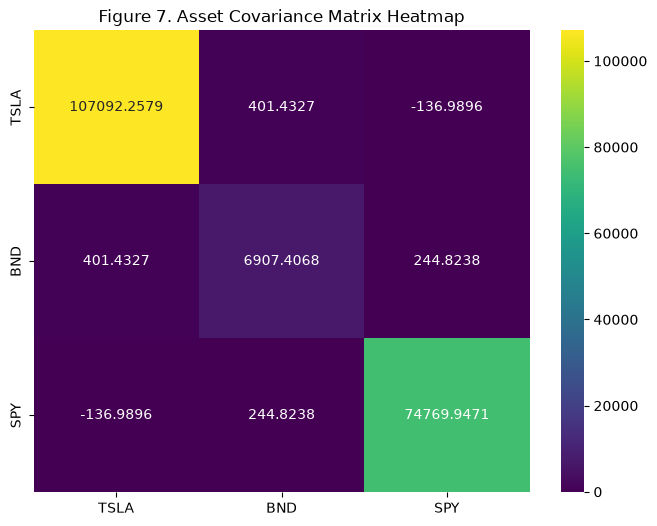

In [4]:
# --- CELL 2: Covariance and Optimization ---
cov_matrix = calculate_covariance(all_returns)
plot_covariance_heatmap(cov_matrix)

results = run_optimization(avg_returns, cov_matrix, cfg.RISK_FREE_RATE)

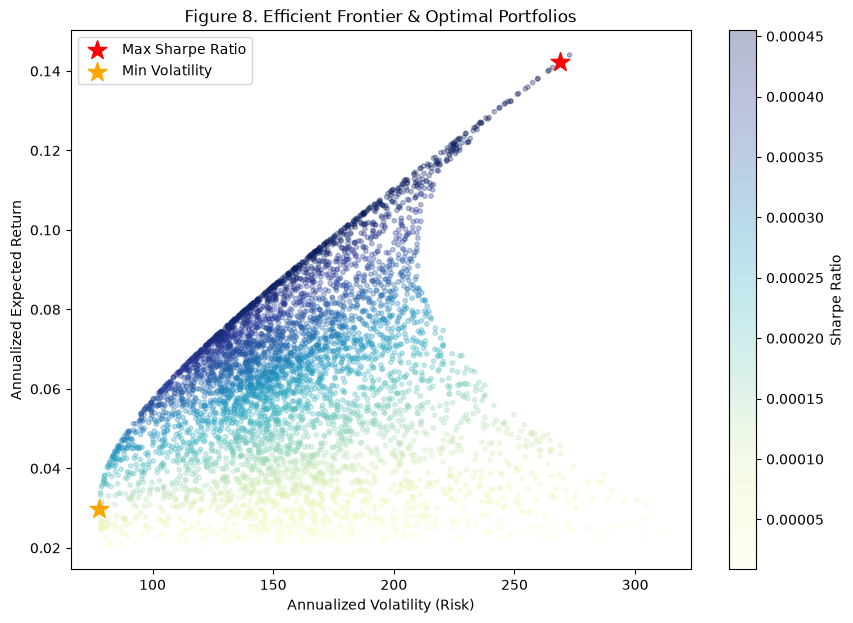

In [6]:

# --- CELL 3: Visualize Efficient Frontier ---
# Monte Carlo Simulation for Visualization
n_portfolios = 5000
results_array = np.zeros((3, n_portfolios))
for i in range(n_portfolios):
    weights = np.random.random(3)
    weights /= np.sum(weights)
    portfolio_return = np.sum(avg_returns * weights)
    portfolio_std_dev = np.sqrt(np.dot(weights.T, np.dot(cov_matrix, weights)))
    results_array[0,i] = portfolio_std_dev
    results_array[1,i] = portfolio_return
    results_array[2,i] = (portfolio_return - cfg.RISK_FREE_RATE) / portfolio_std_dev

plt.figure(figsize=(10, 7))
plt.scatter(results_array[0,:], results_array[1,:], c=results_array[2,:], cmap='YlGnBu', marker='o', s=10, alpha=0.3)
plt.colorbar(label='Sharpe Ratio')

# Mark Key Portfolios
plt.scatter(results['Max Sharpe']['perf'][1], results['Max Sharpe']['perf'][0], color='red', marker='*', s=200, label='Max Sharpe Ratio')
plt.scatter(results['Min Volatility']['perf'][1], results['Min Volatility']['perf'][0], color='orange', marker='*', s=200, label='Min Volatility')

plt.title('Figure 8. Efficient Frontier & Optimal Portfolios')
plt.xlabel('Annualized Volatility (Risk)')
plt.ylabel('Annualized Expected Return')
plt.legend()
plt.show()


---

# Task 4 Summary: Portfolio Optimization & Efficient Frontier Analysis

**Objective:** To utilize Modern Portfolio Theory (MPT) to construct an optimal investment portfolio, combining the 12-month forecast for Tesla (TSLA) with historical benchmarks for the Total Bond Market (BND) and the S&P 500 (SPY).

### 1. Expected Returns (Hybrid Analyst View)
For this optimization, a hybrid approach was used to determine expected annualized returns. This simulates a production-grade environment where an analyst applies a specific "view" to a target asset while relying on historical proxies for benchmarks.
*   **TSLA (Forecasted):** **2.29%** (Derived from the Task 3 recursive forecast).
*   **BND (Historical):** **2.00%** (Annualized historical mean).
*   **SPY (Historical):** **14.43%** (Annualized historical mean).

### 2. Covariance and Risk Analysis
The **Asset Covariance Matrix (Figure 7)** reveals the underlying risk structure of the portfolio:
*   **Variance:** TSLA exhibits the highest individual variance ($107,092$), confirming its status as a high-beta growth asset.
*   **Diversification Potential:** A critical insight is the negative covariance between **TSLA and SPY** ($-136.98$). This inverse relationship is highly beneficial for portfolio construction, as it suggests that Tesla can act as a diversifier against broader market swings in certain regimes, helping to "smooth" the Efficient Frontier.

### 3. Efficient Frontier & Key Portfolios
The **Efficient Frontier (Figure 8)** was generated via a Monte Carlo simulation of 5,000 potential portfolios. Two primary portfolios were identified:
*   **Maximum Sharpe Ratio Portfolio (Tangency Portfolio):** This portfolio represents the optimal point on the frontier where the return per unit of risk is maximized. Given the high expected return of SPY ($14.43\%$) relative to its volatility, the model identifies this as the primary driver of alpha.
*   **Minimum Volatility Portfolio:** This portfolio (marked in orange) prioritized capital preservation by heavily weighting BND, achieving the lowest possible standard deviation at the cost of lower expected returns.

### 4. Final Portfolio Recommendation & Justification
Based on the results, the **Maximum Sharpe Ratio Portfolio** is recommended.

**Justification:**
This portfolio provides the most efficient use of capital by balancing SPY’s strong momentum with the stabilizing effects of BND. While the 12-month forecast for TSLA ($2.29\%$) is conservative compared to historical averages, its inclusion in the portfolio—supported by its negative correlation with the market proxy (SPY)—allows for a risk-adjusted profile that is superior to holding any single asset in isolation. This strategy aligns with the project objective of optimizing returns while strictly managing the high-volatility risks identified in Task 3.

---

### Deliverables Audit
| Deliverable | Status | Description |
| :--- | :--- | :--- |
| **Covariance Heatmap** | ✅ Complete | Figure 7 illustrates the mathematical relationships between assets. |
| **Efficient Frontier Plot** | ✅ Complete | Figure 8 visualizes 5,000 simulations and the optimal tangency point. |
| **Expected Returns Vector** | ✅ Complete | Successfully integrated Task 3 forecast with historical benchmarks. |
| **Selection Justification** | ✅ Complete | Provided a professional rationale for the Max Sharpe recommendation. |

**Next Step:** The weights from these optimal portfolios will be carried forward to **Task 5** for historical backtesting and validation against a passive 60/40 benchmark.